In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv('play_tennis.csv')

In [ ]:
df


,day,outlook,temp,humidity,wind,play
0,D1,Sunny,Hot,High,Weak,No
1,D2,Sunny,Hot,High,Strong,No
2,D3,Overcast,Hot,High,Weak,Yes
3,D4,Rain,Mild,High,Weak,Yes
4,D5,Rain,Cool,Normal,Weak,Yes
5,D6,Rain,Cool,Normal,Strong,No
6,D7,Overcast,Cool,Normal,Strong,Yes
7,D8,Sunny,Mild,High,Weak,No
8,D9,Sunny,Cool,Normal,Weak,Yes
9,D10,Rain,Mild,Normal,Weak,Yes


In [ ]:
#Problem 1
#Outlook = Sunny Temp = Hot, Humidity = High ,  Wind = Weak

In [ ]:
# Solultion
# P (Yes | Sunny, Hot, High , Weak) = P(sunny| yes)* P(Hot| Yes) * P(High| Yes) * P(Weak|Yes)

In [ ]:
#Training
# Look up table( Dictionary)

In [ ]:
df['play'].value_counts()

,count
play,
Yes,9
No,5


In [ ]:
py = 9/14
pn = 5/14

In [ ]:
# Outlook column
pd.crosstab(df['outlook'],df['play'])

play,No,Yes
outlook,,
Overcast,0,4
Rain,2,3
Sunny,3,2


In [ ]:
Pon = 0
Prn = 2/5
Psn = 3/5

Poy = 4/9
Pry = 3/9
Psy = 2/9

In [ ]:
# temp column
pd.crosstab(df['temp'],df['play'])

play,No,Yes
temp,,
Cool,1,3
Hot,2,2
Mild,2,4


In [ ]:
PCoolNo = 1/5
PHotNo = 2/5
PMildNo = 2/5

PCoolYes = 3/9
PHotYes = 2/9
PMildYes = 4/9

In [ ]:
# Humidity column
pd.crosstab(df['humidity'],df['play'])

play,No,Yes
humidity,,
High,4,3
Normal,1,6


In [ ]:
PHighNo = 4/5
PNormalNo = 1/5

PHighYes = 3/9
PNormalYes = 6/9

In [ ]:
# WIND column
pd.crosstab(df['wind'],df['play'])

play,No,Yes
wind,,
Strong,3,3
Weak,2,6


In [ ]:
PStrongNo = 3/5
PWeakNo = 2/5

PStrongYes = 3/9
PWeakYes = 6/9

In [ ]:
#Problem 1
#Outlook = Sunny Temp = Hot, Humidity = High ,  Wind = Weak
Pyes = py * Psy * PHotYes * PHighYes * PWeakYes
Pno = pn * Psn * PHotNo * PHighNo * PWeakNo

Pyes,Pno

(0.007054673721340388, 0.02742857142857143)

Kernel Trick SVM

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

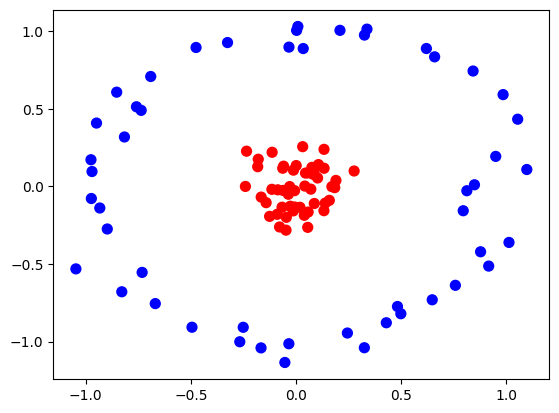

In [ ]:
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr')

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

In [ ]:
classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train.ravel())
y_pred = classifier.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.45

In [ ]:
zero_one_colourmap = ListedColormap(('blue','red'))
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1,
                                 stop = X_set[:, 0].max() + 1,
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1,
                                 stop = X_set[:, 1].max() + 1,
                                 step = 0.01))

    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(),
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75,
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

/tmp/ipykernel_658/2275025531.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


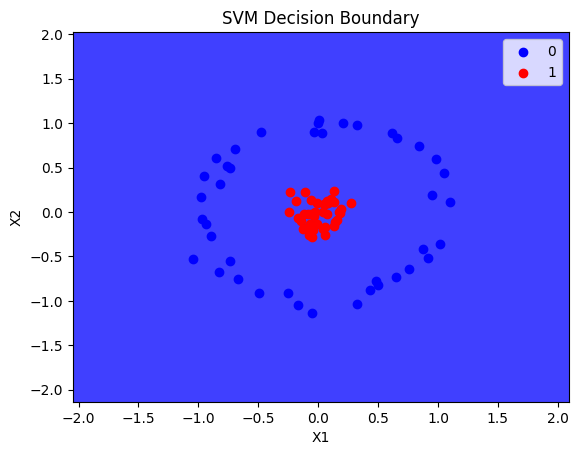

In [ ]:

plot_decision_boundary(X_train, y_train, classifier)

In [ ]:
def plot_3d_plot(X, y):
    r = np.exp(-(X ** 2).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

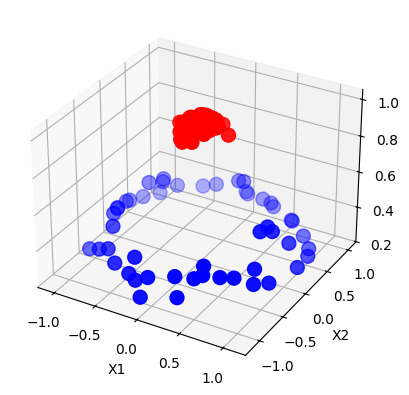

In [ ]:
plot_3d_plot(X,y)

In [ ]:
rbf_classifier = SVC(kernel="rbf")
rbf_classifier.fit(X_train, y_train)
y_pred = rbf_classifier.predict(X_test)

In [ ]:
accuracy_score(y_test, y_pred)

1.0

/tmp/ipykernel_658/2275025531.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


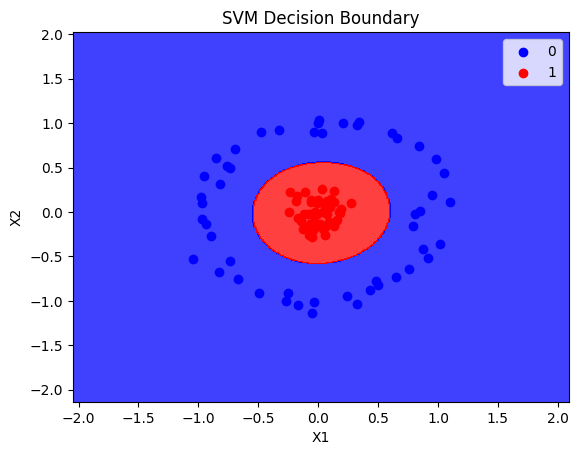

In [ ]:
plot_decision_boundary(X, y, rbf_classifier)

In [ ]:
poly_classifier = SVC(kernel="poly",degree=2
                      )
poly_classifier.fit(X_train, y_train)
y_pred = poly_classifier.predict(X_test)

In [ ]:

accuracy_score(y_test, y_pred)

1.0

/tmp/ipykernel_658/2275025531.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


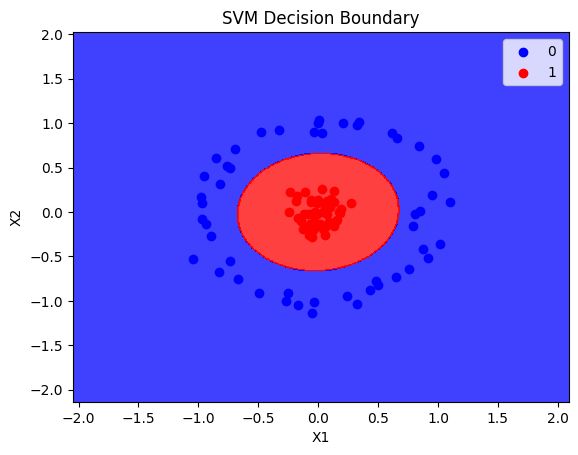

In [ ]:
plot_decision_boundary(X, y, poly_classifier)

In [ ]:
X

array([[ 6.47703773e-01, -7.30829952e-01],
       [-5.92932246e-02,  1.30834530e-01],
       [-7.83271334e-02, -2.61261139e-01],
       [ 8.16959762e-02,  7.85673992e-02],
       [-1.65838786e-01, -6.85140875e-02],
       [ 3.91449051e-02, -1.85977447e-01],
       [ 8.65032284e-03,  1.03175476e+00],
       [-3.02816382e-02, -8.51673284e-04],
       [-4.95005683e-01, -9.07775496e-01],
       [ 1.02516141e-01,  5.47148386e-02],
       [ 1.38855124e-01, -1.07300009e-01],
       [ 3.41030645e-02,  8.89454514e-01],
       [-3.37955988e-02,  8.98657384e-01],
       [-1.35281651e-02, -1.57514400e-01],
       [ 5.88364732e-02,  8.75440639e-02],
       [-8.67302733e-02, -2.17345037e-02],
       [-5.32136817e-02, -1.13514835e+00],
       [-9.49150405e-01,  4.08802672e-01],
       [-3.42406643e-02, -1.01436741e+00],
       [ 3.24867126e-01, -1.04003025e+00],
       [-6.10965378e-02, -2.57619134e-02],
       [-1.82417082e-01,  1.27505532e-01],
       [-4.77428055e-02, -2.81696407e-01],
       [-2.

In [ ]:
np.exp(-(X**2)).sum(1)

array([1.24355151, 1.97951849, 1.92790368, 1.98719417, 1.96818907,
       1.96447255, 1.34481927, 1.99908272, 1.2213293 , 1.98655624,
       1.96945667, 1.4521702 , 1.44479216, 1.97531148, 1.98890958,
       1.9920338 , 1.27283928, 1.25230779, 1.35621341, 1.23887097,
       1.99561072, 1.95114535, 1.92143714, 1.37709231, 1.96902409,
       1.91664617, 1.98653104, 1.95846916, 1.30027484, 1.0832233 ,
       1.24958799, 1.9713798 , 1.93965829, 1.98177323, 1.96982419,
       1.96316056, 1.92672392, 1.23633394, 1.14487751, 1.28988574,
       1.98340119, 1.29352179, 1.99613876, 1.93779801, 1.32069698,
       1.94361271, 1.36703654, 1.29764634, 1.08789186, 1.06665809,
       1.41681947, 1.37406161, 1.96027736, 1.38063006, 1.96868104,
       1.20388886, 1.51612145, 1.3218037 , 1.98048199, 1.95901601,
       1.9792943 , 1.2879372 , 1.96909365, 1.9778438 , 1.39925823,
       1.98203989, 1.98884767, 1.34161353, 1.15758657, 1.99054193,
       1.9822433 , 1.38149561, 1.98311768, 1.9982492 , 1.99922

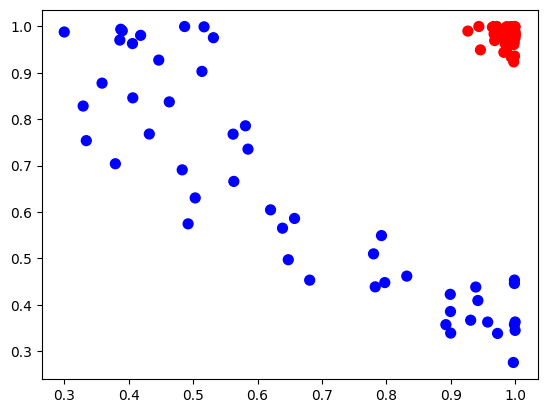

In [ ]:
X_new=np.exp(-(X**2))
plt.scatter(X_new[:, 0], X_new[:, 1], c=y, s=50, cmap='bwr')